In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import time
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))

from my_functions import *
import json
import gc
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [2]:
n_dif=3
ldif=2
jdif=2
def get_system_pair_list_theta(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, thetas: np.ndarray, erange, r, b, e
) -> list[pi.SystemPair]:


    basis1 = pi.BasisAtom(ket1.species, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))
    basis2 = pi.BasisAtom(ket2.species, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))



    system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True), pi.SystemAtom(basis2).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True)


    pi.diagonalize([system1, system2])

    pair_energy = system1.get_corresponding_energy(ket1, unit=energy_unit) + system2.get_corresponding_energy(ket2, unit=energy_unit)
    min_energy, max_energy = pair_energy - erange, pair_energy + erange

    pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )

    pair_systems = []
    for i, theta in enumerate(thetas):
                
        # print(f'pair energy = {pair_energy}{energy_unit}')
            
        
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(r, unit='um', angle_degree=theta).set_interaction_order(3))
            
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )
    
    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in pair_systems]

    return pair_systems, states_num, energies


In [3]:
energy_unit = 'MHz'
atom1, atom2 = 'Rb', 'Cs'
l1_0, l2_0 = 2, 2
j1_0, j2_0 = 3/2, 5/2
l1_1, l2_1 = 1, 3

channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)
channel=3
c=channels.iloc[channel]

r = 2
theta=0
b=0
e=0


n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0']
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
mj1, mj2 = mj1_0s[-1], mj2_0s[-1]
defect = c['defect']
erange = abs(defect*2000)

n1s = np.arange(n1_0-5, n1_0+6)
n2s = np.arange(n2_0-5, n2_0+6)

# Run file tag
run_tag = f'\\r {r}um, theta {theta}deg, b {b}G, erange{round(erange, 2)}, nljdiff{n_dif}{ldif}{jdif}, nranges {n1s[-1]-n1s[0]}'
print(run_tag)

# time log, run log data paths
runlog_datapath = fr'E:\\Tommy uni stuff\\Project\\Data\\logs\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\run logs\\Asym Grids\\'
if not os.path.exists(runlog_datapath):
    os.makedirs(runlog_datapath)

timelog_datapath = fr'E:\\Tommy uni stuff\\Project\\Data\\logs\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\time logs\\Asym Grids\\'
if not os.path.exists(timelog_datapath):
    os.makedirs(timelog_datapath)

   Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  ...  \
0           3    45     2   1.5    51     2   2.5    46     1   0.5  ...   
1           2    45     2   1.5    51     2   2.5    46     1   0.5  ...   
2           6    47     2   1.5    54     2   2.5    48     1   1.5  ...   
3           4    53     2   1.5    60     2   2.5    54     1   0.5  ...   
4           5    53     2   1.5    60     2   2.5    54     1   0.5  ...   
5           8    54     2   1.5    62     2   2.5    55     1   1.5  ...   
6           0    59     2   1.5    57     2   2.5    61     1   0.5  ...   
7           1    59     2   1.5    57     2   2.5    61     1   0.5  ...   
8           7    61     2   1.5    69     2   2.5    62     1   0.5  ...   

   asymmetry 4um  energy 4um  asymmetry 3um  energy 3um  energy_Rb 3um  \
0    -583.190951  -34.489343     -28.409727  -93.572437     -11.269094   
1    -472.400891  -34.617153     -47.273165  -94.268968      -4.130529   
2     -89.981441 

In [19]:
# interaction energy calculation
grid_es = {'n1s' : n1s, 'n2s': n2s}

datapath_grids = fr'E:\\Tommy uni stuff\\Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\inter'
if not os.path.exists(datapath_grids):
    os.makedirs(datapath_grids)

# runlog open
if os.path.exists(runlog_datapath + f'Inter energy calculation.csv'):
    
    run_log = pd.read_csv(runlog_datapath + f'Inter energy calculation.csv')
else:
    run_log = pd.DataFrame({'timestamp' : [],'total time' : [], 'n_dif' : [], 'l_dif' : [], 'j_dif' : [], 'n1_range' : [], 'n2_range' : [], 'erange' : [], 'r' : [], 'B-field' : [], 'E-field' : [], 'theta' : []})

t0 = time.time()
for n1 in n1s:
    es = []
    for n2 in n2s:


        ket1 = pi.KetAtom(atom1, n=n1, l=l1_0, m=j1_0, j=j1_0)
        ket2 = pi.KetAtom(atom2, n=n2, l=l2_0, m=j2_0, j=j2_0)



        pairs = get_system_pair_list_theta(ket1, ket2, [theta], erange, r, b, e)
        pairs_big = get_system_pair_list_theta(ket1, ket2, [theta], erange, 5000, b, e)
        
        
        system_pairs = pairs[0]
        energies = pairs[2]

        overlaps_inter = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]
        overlaps_inter_big = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in pairs_big[0]]

        energy = energies[0][list(overlaps_inter[0]).index(max(overlaps_inter[0], key=abs))]-pairs_big[2][0][list(overlaps_inter_big[0]).index(max(overlaps_inter_big[0], key=abs))]
        
        es.append(energy)
        
    grid_es.update({f'{n1}': es}) 

# logs - save
timestamp=time.strftime("%Y-%m-%d %H:%M:%S")

run_log_single = {'timestamp' : timestamp,'total time' : time.time()-t0, 'n_dif' : n_dif, 'l_dif' : ldif, 'j_dif' : jdif, 'n1_range' : n1s[-1] - n1s[0], 'n2_range' : n2s[-1] - n2s[0], 'erange' : erange, 'r' : r, 'B-field' : b, 'E-field' : e, 'theta' : theta}

run_log = pd.concat([run_log, pd.DataFrame([run_log_single])], ignore_index=True)

pd.DataFrame(run_log).to_csv(runlog_datapath + f'Inter energy calculation.csv', index=False)

# data - save
pd.DataFrame(grid_es).to_csv(datapath_grids + run_tag + '.csv', index=False)

# Clearing memory
del run_log, run_log_single, grid_es, es, pairs, pairs_big, system_pairs, energies, overlaps_inter, overlaps_inter_big, energy
collected = gc.collect()


A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.
A bijective map between states and kets could not be found.


In [20]:
# Rb energy calculation

# File destinations
# data
datapath_gridsRb = fr'E:\\Tommy uni stuff\\Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\intra Rb'
if not os.path.exists(datapath_gridsRb):
    os.makedirs(datapath_gridsRb)
    
grid_es_rb = {'n1s' : n1s, 'n2s': n2s}

t0_Rb = time.time()

# timelog open
if os.path.exists(timelog_datapath + f'Rb energy calculation'):
    with open(timelog_datapath + f'Rb energy calculation', 'r') as f:
        t_log = json.load(f)
    
else:
    t_log = {}

# runlog open
if os.path.exists(runlog_datapath + f'Rb energy calculation.csv'):
    
    run_log = pd.read_csv(runlog_datapath + f'Rb energy calculation.csv')
else:
    run_log = pd.DataFrame({'timestamp' : [],'total time' : [], 'n_dif' : [], 'l_dif' : [], 'j_dif' : [], 'n1_range' : [], 'n2_range' : [], 'erange' : [], 'r' : [], 'B-field' : [], 'E-field' : [], 'theta' : []})
print(run_log)
# Experiment run
t={}

for n1 in n1s:
    
    es_rb = []
    for n2 in n2s:


        ket1 = pi.KetAtom(atom1, n=n1, l=l1_0, m=j1_0, j=j1_0)


        # Rb
        pairs_Rb = get_system_pair_list_theta(ket1, ket1, [theta], erange, r, b, e)
        pairs_big_Rb = get_system_pair_list_theta(ket1, ket1, [theta], erange, 5000, b, e)
        
        system_pairs_Rb = pairs_Rb[0]
        energies_Rb = pairs_Rb[2]

        overlaps_inter_Rb = [system.get_eigenbasis().get_overlaps([ket1, ket1]) for system in system_pairs_Rb]
        overlaps_inter_big_Rb = [system.get_eigenbasis().get_overlaps([ket1, ket1]) for system in pairs_big_Rb[0]]

        energy_Rb = energies_Rb[0][list(overlaps_inter_Rb[0]).index(max(overlaps_inter_Rb[0], key=abs))]-pairs_big_Rb[2][0][list(overlaps_inter_big_Rb[0]).index(max(overlaps_inter_big_Rb[0], key=abs))]
        

        es_rb.append(energy_Rb)
    # t.update({f'n1:{n1}': np.round(time.time()-t0_Rb, 2)})
    grid_es_rb.update({f'{n1}': es_rb})
    print(f'{list(n1s).index(n1)/len(n1s)*100:.2f}%') 


# logs - save
timestamp=time.strftime("%Y-%m-%d %H:%M:%S")

run_log_single = {'timestamp' : timestamp,'total time' : time.time()-t0_Rb, 'n_dif' : n_dif, 'l_dif' : ldif, 'j_dif' : jdif, 'n1_range' : n1s[-1] - n1s[0], 'n2_range' : n2s[-1] - n2s[0], 'erange' : erange, 'r' : r, 'B-field' : b, 'E-field' : e, 'theta' : theta}

run_log = pd.concat([run_log, pd.DataFrame([run_log_single])], ignore_index=True)

pd.DataFrame(run_log).to_csv(runlog_datapath + f'Rb energy calculation.csv', index=False)

# data - save
pd.DataFrame(grid_es_rb).to_csv(datapath_gridsRb + run_tag + '.csv', index=False)

# Clearing memory
del run_log, run_log_single, grid_es_rb, es_rb, pairs_Rb, pairs_big_Rb, system_pairs_Rb, energies_Rb, overlaps_inter_Rb, overlaps_inter_big_Rb, energy_Rb
collected = gc.collect()

              timestamp  total time  n_dif  l_dif  j_dif  n1_range  n2_range  \
0      15/09/2026 11:28   86.348982      3      3      3       -10       -10   
1      15/09/2026 11:33  107.592484      3      3      3       -10       -10   
2   2026-09-15 15:49:46   36.664982      3      3      3       -10       -10   
3   2026-09-18 12:05:22   41.651297      3      3      3        10        10   
4   2026-09-18 12:18:57   43.508833      3      3      3        10        10   
5   2026-09-18 12:32:25   72.268205      3      3      3        10        10   
6   2026-09-23 14:31:14   51.632092      2      2      2        10        10   
7   2026-09-23 15:19:37  100.332313      2      2      2        10        10   
8   2026-09-25 12:11:59   71.145513      3      2      2        10        10   
9   2026-09-25 14:45:27   78.577841      3      2      2        10        10   
10  2026-09-25 16:00:50  134.720593      3      2      2        10        10   
11  2026-09-25 17:01:45   83.512119     

In [4]:

# Cs energy calculation
datapath_gridsCs = fr'E:\\Tommy uni stuff\\Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\intra Cs'
if not os.path.exists(datapath_gridsCs):
    os.makedirs(datapath_gridsCs)

# runlog open
if os.path.exists(runlog_datapath + f'Cs energy calculation.csv'):
    
    run_log = pd.read_csv(runlog_datapath + f'Cs energy calculation.csv')
else:
    run_log = pd.DataFrame({'timestamp' : [],'total time' : [], 'n_dif' : [], 'l_dif' : [], 'j_dif' : [], 'n1_range' : [], 'n2_range' : [], 'erange' : [], 'r' : [], 'B-field' : [], 'E-field' : [], 'theta' : []})

grid_es_cs = {'n1s' : n1s, 'n2s': n2s}

t0_Cs = time.time()

for n1 in n1s:
    es_cs = []
    for n2 in n2s:


        ket2 = pi.KetAtom(atom2, n=n2, l=l2_0, m=j2_0, j=j2_0)

        # Cs
        pairs_Cs = get_system_pair_list_theta(ket2, ket2, [theta], erange, r, b, e)
        pairs_big_Cs = get_system_pair_list_theta(ket2, ket2, [theta], erange, 5000, b, e)

        system_pairs_Cs = pairs_Cs[0]
        energies_Cs = pairs_Cs[2]

        overlaps_inter_Cs = [system.get_eigenbasis().get_overlaps([ket2, ket2]) for system in system_pairs_Cs]
        overlaps_inter_big_Cs = [system.get_eigenbasis().get_overlaps([ket2, ket2]) for system in pairs_big_Cs[0]]
        energy_Cs = energies_Cs[0][list(overlaps_inter_Cs[0]).index(max(overlaps_inter_Cs[0], key=abs))]-pairs_big_Cs[2][0][list(overlaps_inter_big_Cs[0]).index(max(overlaps_inter_big_Cs[0], key=abs))]
        es_cs.append(energy_Cs)
        
    grid_es_cs.update({f'{n1}': es_cs}) 
    print(f'{list(n1s).index(n1)/len(n1s)*100:.2f}%')

# logs - save
timestamp=time.strftime("%Y-%m-%d %H:%M:%S")

run_log_single = {'timestamp' : timestamp,'total time' : time.time()-t0_Cs, 'n_dif' : n_dif, 'l_dif' : ldif, 'j_dif' : jdif, 'n1_range' : n1s[-1] - n1s[0], 'n2_range' : n2s[-1] - n2s[0], 'erange' : erange, 'r' : r, 'B-field' : b, 'E-field' : e, 'theta' : theta}

run_log = pd.concat([run_log, pd.DataFrame([run_log_single])], ignore_index=True)

pd.DataFrame(run_log).to_csv(runlog_datapath + f'Cs energy calculation.csv', index=False)

# data - save
pd.DataFrame(grid_es_cs).to_csv(datapath_gridsCs + run_tag + '.csv', index=False)

# Clearing memory
del run_log, run_log_single, grid_es_cs, es_cs, pairs_Cs, pairs_big_Cs, system_pairs_Cs, energies_Cs, overlaps_inter_Cs, overlaps_inter_big_Cs, energy_Cs
collected = gc.collect()


0.00%
9.09%
18.18%
27.27%
36.36%
45.45%
54.55%
63.64%
72.73%
81.82%
90.91%


In [5]:
# Asym Grids calculation

datapath_gridsAsym = fr'E:\\Tommy uni stuff\\Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\Asym'
if not os.path.exists(datapath_gridsAsym):
    os.makedirs(datapath_gridsAsym)

datapath_grids = fr'E:\\Tommy uni stuff\\Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\inter'
datapath_gridsRb = fr'E:\\Tommy uni stuff\\Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\intra Rb'
datapath_gridsCs = fr'E:\\Tommy uni stuff\\Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\intra Cs'

energies = pd.read_csv(datapath_grids + run_tag + '.csv')
Rb_energies = pd.read_csv(datapath_gridsRb + run_tag + '.csv')
Cs_energies = pd.read_csv(datapath_gridsCs + run_tag + '.csv')

grid_asyms = {'n1s' : n1s, 'n2s': n2s}
for n1 in n1s:
    asyms = []
    for n2 in n2s:
        energy = energies[f'{n1}'][n2s.tolist().index(n2)]
        energy_Rb = Rb_energies[f'{n1}'][n2s.tolist().index(n2)]
        energy_Cs = Cs_energies[f'{n1}'][n2s.tolist().index(n2)]
        ket1 = pi.KetAtom(atom1, n=n1, l=l1_0, m=j1_0, j=j1_0)
        ket2 = pi.KetAtom(atom2, n=n2, l=l2_0, m=j2_0, j=j2_0)

        asym = energy/np.sqrt(abs(energy_Rb*energy_Cs))
        
        # print(f'channel {i}')
        print(f'energy = {energy}MHz, Rb small = {energy_Rb}MHz, Cs small = {energy_Cs}MHz')
        print(f'Ket1: {ket1}, Ket2: {ket2}')
        print(f'r = {r}um, theta {theta}deg, b = {b}G, asym = {asym}')

        asyms.append(asym)
        
    grid_asyms[f'{n1}'] = asyms

pd.DataFrame(grid_asyms).to_csv(datapath_gridsAsym + run_tag + '.csv', index=False)


energy = 191.35456800460813MHz, Rb small = -488.8242111206055MHz, Cs small = 40.15341901779175MHz
Ket1: |Rb:48,D_3/2,3/2⟩, Ket2: |Cs:55,D_5/2,5/2⟩
r = 2um, theta 0deg, b = 0G, asym = 1.3658443631624937
energy = 190.43345308303836MHz, Rb small = -488.8242111206055MHz, Cs small = 50.27405452728272MHz
Ket1: |Rb:48,D_3/2,3/2⟩, Ket2: |Cs:56,D_5/2,5/2⟩
r = 2um, theta 0deg, b = 0G, asym = 1.214772445949412
energy = 117.1776795387268MHz, Rb small = -488.8242111206055MHz, Cs small = 62.96891903877258MHz
Ket1: |Rb:48,D_3/2,3/2⟩, Ket2: |Cs:57,D_5/2,5/2⟩
r = 2um, theta 0deg, b = 0G, asym = 0.6678907372333327
energy = 159.23070573806763MHz, Rb small = -488.8242111206055MHz, Cs small = 78.99786400794983MHz
Ket1: |Rb:48,D_3/2,3/2⟩, Ket2: |Cs:58,D_5/2,5/2⟩
r = 2um, theta 0deg, b = 0G, asym = 0.8102943143567439
energy = 352.3382213115692MHz, Rb small = -488.8242111206055MHz, Cs small = 99.4167070388794MHz
Ket1: |Rb:48,D_3/2,3/2⟩, Ket2: |Cs:59,D_5/2,5/2⟩
r = 2um, theta 0deg, b = 0G, asym = 1.59828313400

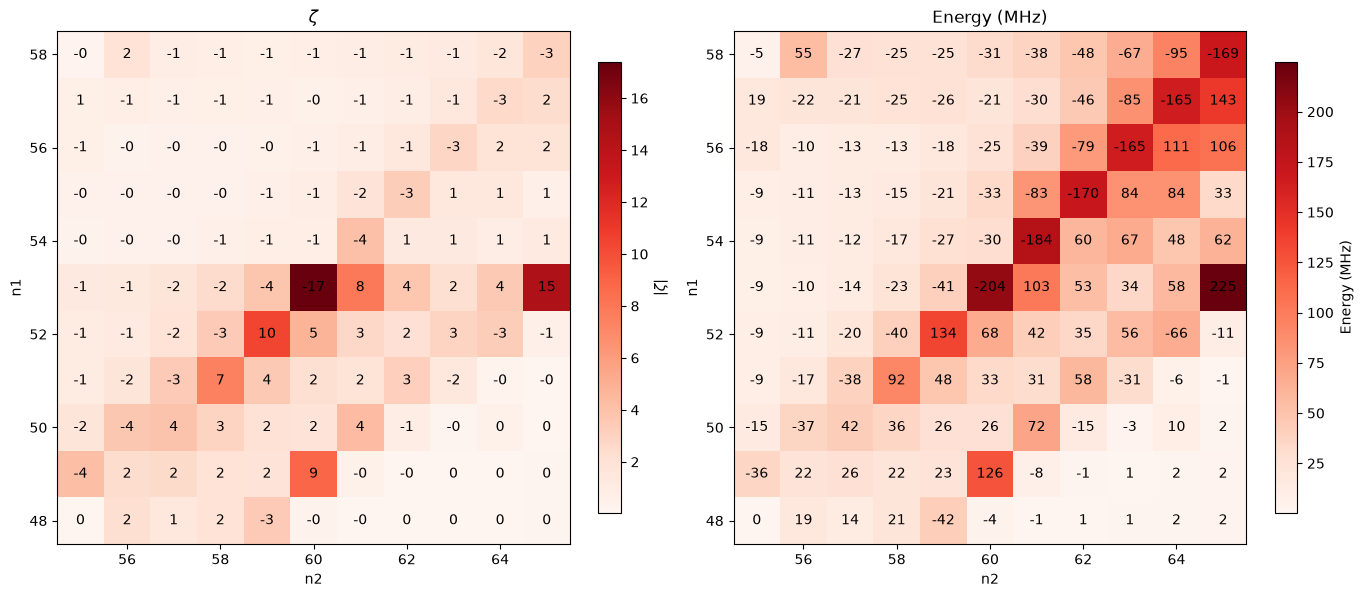

In [10]:
r=3
run_tag = f'\\r {r}um, theta {theta}deg, b {b}G, erange{round(erange, 2)}, nljdiff{n_dif}{ldif}{jdif}, nranges {n1s[-1]-n1s[0]}'

datapath_gridsAsym = f'E:\\Tommy uni stuff\\Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\Asym'

datapath_grids = fr'E:\\Tommy uni stuff\\Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\inter'


grid_asyms = pd.read_csv(datapath_gridsAsym + run_tag + '.csv')
grid_es = pd.read_csv(datapath_grids + run_tag + '.csv')
n1s = grid_asyms['n1s'].to_numpy()
n2s = grid_asyms['n2s'].to_numpy()

fig, ax = plt.subplots(ncols=2, figsize=(16,8))
im = ax[0].imshow(list(abs(np.transpose(grid_asyms.to_numpy())))[2:], extent=(n2s[0]-1/2, n2s[-1]+1/2, n1s[0]-1/2, n1s[-1]+1/2), origin='lower', cmap='Reds')

plt.colorbar(im, ax=ax[0], label=r'$|\zeta|$',fraction=0.04)

im1 = ax[1].imshow(list(abs(np.transpose(grid_es.to_numpy())))[2:], extent=(n2s[0]-1/2, n2s[-1]+1/2, n1s[0]-1/2, n1s[-1]+1/2), origin='lower', cmap='Reds')

plt.colorbar(im1, ax=ax[1], label='Energy (MHz)', norm=mcolors.SymLogNorm(linthresh=1, vmin=np.min(list(abs(np.transpose(grid_es.to_numpy())))[2:]), vmax=np.max(list(abs(np.transpose(grid_es.to_numpy())))[2:])),fraction=0.04)

ax[0].set_title(r'$\zeta$')
ax[0].set_xlabel('n2') 
ax[0].set_ylabel('n1')

ax[1].set_title('Energy (MHz)')
ax[1].set_xlabel('n2') 
ax[1].set_ylabel('n1')

for i in range(len(n1s)):
    for j in range(len(n2s)):
        text = ax[0].text(n2s[j], n1s[i], f'{np.round(grid_asyms[f"{n1s[i]}"][j],2):.0f}', ha='center', va='center', color='black')

for i in range(len(n1s)):
    for j in range(len(n2s)):
        text = ax[1].text(n2s[j], n1s[i], f'{np.round(grid_es[f"{n1s[i]}"][j],0):.0f}', ha='center', va='center', color='black')

figpath = fr'E:\\Tommy uni stuff\\Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\grids\\Asym'
if not os.path.exists(figpath):
    os.makedirs(figpath)
plt.savefig(figpath + f'{run_tag}.png', bbox_inches='tight', dpi=300)

In [ ]:
print(channels)

In [ ]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular full\\inter intra\\'
if not os.path.exists(datapath + 'inter'):
    os.makedirs(datapath + 'inter')
if not os.path.exists(datapath + 'intra Rb'):
    os.makedirs(datapath + 'intra Rb')
if not os.path.exists(datapath + 'intra Cs'):
    os.makedirs(datapath + 'intra Cs')
    

In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']


for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            import os

            

            ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)

            system_pairs = system_pairs_dict_inter[f'{b}{r}']
            system_pairs_Rb = system_pairs_dict_Rb[f'{b}{r}']
            system_pairs_Cs = system_pairs_dict_Cs[f'{b}{r}']

            overlaps_inter = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]
            overlaps_intra_Rb = [system.get_eigenbasis().get_overlaps([ket1, ket1]) for system in system_pairs_Rb]
            overlaps_intra_Cs = [system.get_eigenbasis().get_overlaps([ket2, ket2]) for system in system_pairs_Cs]

            energies_inter = energies_inter_dict[f'{b}{r}']
            energies_intra_Rb = energies_intra_Rb_dict[f'{b}{r}']
            energies_intra_Cs = energies_intra_Cs_dict[f'{b}{r}']

            # print(energies_inter)
            
                    
            # 2. Build the RGBA array: (N, 4)

            fig, ax = plt.subplots(ncols=1, figsize=(6, 4), subplot_kw={'projection': 'polar'})
            ax.set_theta_zero_location("N")

            plt.tight_layout()
            plt.title(fr'{str(ket1)}{str(ket2)}, r {r}um, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(min_energy, max_energy)
            # plt.xlim(2, 2.7)
            # plt.ylabel(f"Energy [{energy_unit}]")
            plt.xlabel(fr"Energy [{energy_unit}]")
            # ax.plot(e_fields_sub, energies)

            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            theta, energy, overlap = [], [], []
            min_overlap = 0.1
            for x, es, os in zip(thetas, energies_inter, overlaps_inter):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    theta.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[0])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]

                    scat = plt.scatter(
                        np.radians([x] * len(es[inds])),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Reds'
                    )
            overlapped_inter = {'theta' : np.array(theta), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            fig.colorbar(scat, ax=ax, label=fr"$m_j,Rb$ = {int(2*ket1.m)}/2, $m_j,Cs$ = {int(2*ket2.m)}/2")

            theta, energy, overlap = [], [], []
            for x, es, os in zip(thetas, energies_intra_Rb, overlaps_intra_Rb):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    theta.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[1])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]
                    scat = plt.scatter(
                        np.radians([x] * len(es[inds])),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Purples'
                    )
            overlapped_intra_Rb = {'theta' : np.array(theta), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            
            theta, energy, overlap = [], [], []
            for x, es, os in zip(thetas, energies_intra_Cs, overlaps_intra_Cs):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    theta.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[2])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]
                    scat = plt.scatter(
                        np.radians([x] * len(es[inds])),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Blues'
                    )
                    
            plt.show()
            overlapped_intra_Cs = {'theta' : np.array(theta), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            pd.DataFrame(overlapped_inter).to_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            pd.DataFrame(overlapped_intra_Rb).to_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, r {r}um.csv')
            pd.DataFrame(overlapped_intra_Cs).to_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'r {r}um b{np.round(b,3)}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')
            plt.close()


In [ ]:
print(overlapped_intra_Cs)

In [ ]:
import os
datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular full\\inter intra\\field-corrected\\'
if not os.path.exists(datapath_field + 'inter'):
    os.makedirs(datapath_field + 'inter')
if not os.path.exists(datapath_field + 'intra Rb'):
    os.makedirs(datapath_field + 'intra Rb')
if not os.path.exists(datapath_field + 'intra Cs'):
    os.makedirs(datapath_field + 'intra Cs')
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\inter intra\\polar\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]

r = 15
b=0.0
for b in bs[:]:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            overlapped_inter_big = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, r {5000}um.csv')
            overlapped_intra_Rb = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, r {r}um.csv')
            overlapped_intra_Rb_big = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, r {5000}um.csv')
            overlapped_intra_Cs = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            overlapped_intra_Cs_big = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, r {5000}um.csv')

            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4), subplot_kw={'projection': 'polar'})
            # , subplot_kw={'projection': 'polar'}
            ax.set_theta_zero_location("N")
            
            ax.set_xlabel(f"Energy ({energy_unit})")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}) sep = {r}um, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(min_energy, max_energy)
            # ax.set_rlim([0,5])
            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            min_overlap = 0
            j=-1
            energies = {'energy' : [], 'theta' : [], 'overlap' : []}
            # print(overlapped_inter['theta'])
            theta = overlapped_inter['theta'][0]
            # 1. Map theta to energy from the 'big' dataset for O(1) lookup
            # This handles the "search" part instantly
            big_lookup = dict(zip(overlapped_inter_big['theta'], overlapped_inter_big['energy']))

            # 2. Iterate through every single item in the original small dataset
            for j, theta in enumerate(overlapped_inter['theta']):
                current_energy = overlapped_inter['energy'][j]
                
                # 3. Check if this theta exists in our big lookup table
                if theta in big_lookup:
                    # Subtract if match found
                    diff = current_energy - big_lookup[theta]
                    energies['energy'].append(diff)
                else:
                    # If no match, decide what to do: 
                    # Option A: Keep original energy (subtract 0)
                    # Option B: Append None or np.nan to maintain index alignment
                    energies['energy'].append(current_energy) # or None
                    
                # Always append these to keep lengths aligned
                energies['theta'].append(theta)
                energies['overlap'].append(overlapped_inter['overlap'][j])
                    
                    
                    

            # print(energies['energy']-overlapped_inter['energy'])

            scat = plt.scatter(
                np.radians(energies['theta']),
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds'
            )
            fig.colorbar(scat, ax=ax, label=fr"$m_j,Rb$ = {int(2*ket1.m)}/2, $m_j,Cs$ = {int(2*ket2.m)}/2")

            min_overlap = 0
            j=-1
            energies_Rb = {'energy' : [], 'theta' : [], 'overlap' : []}
            # print(overlapped_inter['theta'])
            # 1. Map theta to energy from the 'big' dataset for O(1) lookup
            # This handles the "search" part instantly
            big_lookup = dict(zip(overlapped_intra_Rb_big['theta'], overlapped_intra_Rb_big['energy']))

            # 2. Iterate through every single item in the original small dataset
            for j, theta in enumerate(overlapped_intra_Rb['theta']):
                current_energy = overlapped_intra_Rb['energy'][j]
                
                # 3. Check if this theta exists in our big lookup table
                if theta in big_lookup:
                    # Subtract if match found
                    diff = current_energy - big_lookup[theta]
                    energies_Rb['energy'].append(diff)
                else:
                    # If no match, decide what to do: 
                    # Option A: Keep original energy (subtract 0)
                    # Option B: Append None or np.nan to maintain index alignment
                    energies_Rb['energy'].append(current_energy) # or None
                    
                # Always append these to keep lengths aligned
                energies_Rb['theta'].append(theta)
                energies_Rb['overlap'].append(overlapped_intra_Rb['overlap'][j])

            scat = plt.scatter(
                np.radians(energies_Rb['theta']),
                abs(np.array(energies_Rb['energy'])),
                c=energies_Rb['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Blues'
            )

            j=0
            energies_Cs = {'energy' : [], 'theta' : [], 'overlap' : []}
            # print(overlapped_inter['theta'])
            theta = overlapped_intra_Cs['theta'][j]
            # 1. Map theta to energy from the 'big' dataset for O(1) lookup
            # This handles the "search" part instantly
            big_lookup = dict(zip(overlapped_intra_Cs_big['theta'], overlapped_intra_Cs_big['energy']))

            # 2. Iterate through every single item in the original small dataset
            for j, theta in enumerate(overlapped_intra_Cs['theta']):
                current_energy = overlapped_intra_Cs['energy'][j]
                
                # 3. Check if this theta exists in our big lookup table
                if theta in big_lookup:
                    # Subtract if match found
                    diff = current_energy - big_lookup[theta]
                    energies_Cs['energy'].append(diff)
                else:
                    # If no match, decide what to do: 
                    # Option A: Keep original energy (subtract 0)
                    # Option B: Append None or np.nan to maintain index alignment
                    energies_Cs['energy'].append(current_energy) # or None
                    
                # Always append these to keep lengths aligned
                energies_Cs['theta'].append(theta)
                energies_Cs['overlap'].append(overlapped_intra_Cs['overlap'][j])
                    

            scat = plt.scatter(
                np.radians(energies_Cs['theta']),
                abs(np.array(energies_Cs['energy'])),
                c=energies_Cs['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Greens'
            )
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            pd.DataFrame(energies_Rb).to_csv(datapath_field + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, r {r}um.csv')
            pd.DataFrame(energies_Cs).to_csv(datapath_field + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')
            plt.close()

In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\inter intra\\polar\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]

r = 10
b=0.0
for b in bs[1:2]:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            overlapped_inter_big = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, r {5000}um.csv')
            overlapped_intra_Rb = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, r {r}um.csv')
            overlapped_intra_Rb_big = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, r {5000}um.csv')
            overlapped_intra_Cs = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            overlapped_intra_Cs_big = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, r {5000}um.csv')

            
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4), subplot_kw={'projection': 'polar'})
            # , subplot_kw={'projection': 'polar'}
            ax.set_theta_zero_location("N")
            
            ax.set_xlabel("E_z (mV/cm)")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}) sep = {r}um, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(min_energy, max_energy)
            # ax.set_rlim([0,17])
            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            min_overlap = 0.01
            j=0
            energies = {'energy' : [], 'theta' : [], 'overlap' : []}
            # print(overlapped_inter['theta'])
            theta = overlapped_inter['theta'][0]
            for i, thetaBig in enumerate(overlapped_inter_big['theta']):
                if thetaBig < theta:
                    continue
                while theta < thetaBig:
                    # print(j)
                    if j >= len(overlapped_inter['theta']):
                        break
                    j += 1
                    theta = overlapped_inter['theta'][j]
                    # print(theta, thetaBig)
                    if theta == thetaBig:
                                       
                        energies['energy'].append(overlapped_inter['energy'][j] - overlapped_inter_big['energy'][i])
                        energies['theta'].append(theta)
                        energies['overlap'].append(overlapped_inter['overlap'][j])
                    
            

            scat = plt.scatter(
                np.radians(energies['theta']),
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds'
            )

            j=0
            thetaBig = overlapped_intra_Rb_big['theta'][0]
            energies = {'energy' : [], 'theta' : [], 'overlap' : []}
            # print(overlapped_intra_Rb['theta'])
            theta = overlapped_intra_Rb['theta'][0]
            for i, thetaBig in enumerate(overlapped_intra_Rb_big['theta']):
                if thetaBig < theta:
                    continue
                while theta < thetaBig:
                    # print(j)
                    if j >= len(overlapped_intra_Rb['theta']):
                        break
                    j += 1
                    theta = overlapped_intra_Rb['theta'][j]
                    if theta == thetaBig:
                                       
                        energies['energy'].append(overlapped_intra_Rb['energy'][j])
                        energies['theta'].append(theta)
                        energies['overlap'].append(overlapped_intra_Rb['overlap'][j])
                    
                        
            scat = plt.scatter(
                np.radians(energies['theta']),
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Blues'
            )

            j=0
            thetaBig = overlapped_intra_Cs_big['theta'][0]
            energies = {'energy' : [], 'theta' : [], 'overlap' : []}
            # print(overlapped_intra_Cs['theta'])
            theta = overlapped_intra_Cs['theta'][0]
            for i, thetaBig in enumerate(overlapped_intra_Cs_big['theta']):
                if thetaBig < theta:
                    continue
                while theta < thetaBig:
                    # print(j)
                    if j >= len(overlapped_intra_Cs['theta']):
                        break
                    j += 1
                    theta = overlapped_intra_Cs['theta'][j]
                    if theta == thetaBig:
                        # print(overlapped_intra_Cs['energy'][j] - overlapped_intra_Cs_big['energy'][i])
                        energies['energy'].append(overlapped_intra_Cs['energy'][j])
                        energies['theta'].append(theta)
                        energies['overlap'].append(overlapped_intra_Cs['overlap'][j])
                    

            scat = plt.scatter(
                np.radians(energies['theta']),
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Greens'
            )
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')
            plt.close()

In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\inter intra\\cartesian\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]

r = 5
b=0.0
for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            overlapped_inter_big = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, r {5000}um.csv')
            overlapped_intra_Rb = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, r {r}um.csv')
            overlapped_intra_Rb_big = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, r {5000}um.csv')
            overlapped_intra_Cs = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, r {r}um.csv')
            overlapped_intra_Cs_big = pd.read_csv(datapath + f'inter\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, r {5000}um.csv')


            fig, ax = plt.subplots(ncols=1, figsize=(6, 4), subplot_kw={'projection': 'polar'})
            # , subplot_kw={'projection': 'polar'}
            ax.set_theta_zero_location("N")
            
            ax.set_xlabel("E_z (mV/cm)")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}) sep = {r}um, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(min_energy, max_energy)
            # ax.set_rlim([0,10])
            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            min_overlap = 0.01
            j=0
            thetaBig = overlapped_inter_big['theta'][0]
            energies = {'energy' : [], 'theta' : [], 'overlap' : []}
            # print(overlapped_inter['theta'])
            theta = overlapped_inter['theta'][0]
            for i, thetaBig in enumerate(overlapped_inter_big['theta']):
                if thetaBig < theta:
                    continue
                while theta <= thetaBig:
                    # print(j)
                    if j >= len(overlapped_inter['theta']):
                        break
                    theta = overlapped_inter['theta'][j]
                    if theta == thetaBig:
                                       
                        energies['energy'].append(overlapped_inter['energy'][j] - overlapped_inter_big['energy'][i])
                        energies['theta'].append(theta)
                        energies['overlap'].append(overlapped_inter['overlap'][j])
                        j += 1
            

            scat = plt.scatter(
                np.radians(energies['theta']),
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds'
            )

            j=0
            thetaBig = overlapped_intra_Rb_big['theta'][0]
            energies = {'energy' : [], 'theta' : [], 'overlap' : []}
            print(overlapped_intra_Rb['theta'])
            theta = overlapped_intra_Rb['theta'][0]
            for i, thetaBig in enumerate(overlapped_intra_Rb_big['theta']):
                if thetaBig < theta:
                    continue
                while theta <= thetaBig:
                    # print(j)
                    if j >= len(overlapped_intra_Rb['theta']):
                        break
                    theta = overlapped_intra_Rb['theta'][j]
                    if theta == thetaBig:
                                       
                        energies['energy'].append(overlapped_intra_Rb['energy'][j] - overlapped_intra_Rb_big['energy'][i])
                        energies['theta'].append(theta)
                        energies['overlap'].append(overlapped_intra_Rb['overlap'][j])
                        j += 1
                        
            scat = plt.scatter(
                np.radians(energies['theta']),
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Blues'
            )

            j=0
            thetaBig = overlapped_intra_Cs_big['theta'][0]
            energies = {'energy' : [], 'theta' : [], 'overlap' : []}
            print(overlapped_intra_Cs['theta'])
            theta = overlapped_intra_Cs['theta'][0]
            for i, thetaBig in enumerate(overlapped_intra_Cs_big['theta']):
                if thetaBig < theta:
                    continue
                while theta <= thetaBig:
                    # print(j)
                    if j >= len(overlapped_intra_Cs['theta']):
                        break
                    theta = overlapped_intra_Cs['theta'][j]
                    if theta == thetaBig:
                                       
                        energies['energy'].append(overlapped_intra_Cs['energy'][j] - overlapped_intra_Cs_big['energy'][i])
                        energies['theta'].append(theta)
                        energies['overlap'].append(overlapped_intra_Cs['overlap'][j])
                        j += 1

            scat = plt.scatter(
                np.radians(energies['theta']),
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Greens'
            )

            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')


In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\separations\\overlapped\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\log\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

for mj1 in mj1_0s:
    for mj2 in mj2_0s:

        ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]


        # plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')
        fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlabel("E_z (mV/cm)")
        ax.set_ylabel(f"Energy ({energy_unit})")
        ax.set_title(fr'separations $\mu$m')
        plt.tight_layout()
        plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')
        energy_lim = abs(defect + defect*2)
        offset=defect/2
        min_energy = -energy_lim+offset
        max_energy = energy_lim+offset
        # plt.ylim(min_energy, max_energy)
        # plt.xlim(2, 2.7)
        plt.ylabel(f"Energy [{energy_unit}]")
        plt.xlabel("Magnetic Field [G]")
        # ax.plot(e_fields_sub, energies)

        for x, es in zip(rs, energies):
            plt.plot([x] * len(es), abs(es), c='.7', ls="None", marker=".", ms=1, zorder=-1)
        min_overlap = 0.000
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
        fig.colorbar(scat, ax=ax, label=fr"$m_j$ = {ket1.m}, $m_j$ = {ket2.m}")
        # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
        fig.savefig(figpath + f'level pairstate deg{angle} b{b}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')


In [ ]:
min_overlap = 0.1
energies_dict_0 = {f'mjs0{mj1_0}{mj2_0}': [] for mj1_0 in mj1_0s for mj2_0 in mj2_0s}
print(energies_dict_0)
fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("E_z (mV/cm)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

for mj1_0 in mj1_0s:
    for mj2_0 in mj2_0s:
        ket1_0 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1_0)
        ket2_0 = pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2_0)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1_0, ket2_0]) for system in system_pairs]

        energies1=[]
        ds=[]
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
                energies1 = np.append(energies1, es[inds])
                ds = np.append(ds, [x] * len(es[inds]))
        energies_dict_0[f'rs{mj1_0}{mj2_0}'] = ds
        energies_dict_0[f'mjs0{mj1_0}{mj2_0}'] = energies1

In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)

def func(r, c):
    return c/(r)**3 
rmax=10.5
mj1_0, mj2_0 = -1/2, -1/2
ds = energies_dict_0[f'rs{mj1_0}{mj2_0}']
print(ds)
ds = ds[np.argwhere(ds<rmax)].flatten()[::2]

energy = energies_dict_0[f'mjs0{mj1_0}{mj2_0}']
energy = energy[np.argwhere(ds<rmax)].flatten()
print(len(ds), len(energy))
popt, pcov = scipy.optimize.curve_fit(func, ds, energy)
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r"r ($\mu$m)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

ax.plot(ds, abs(energy))
ax.plot(ds, abs(func(ds, *popt)), linestyle='dashed', color='red')
fig.savefig(figpath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.png')
print(pcov)
C3 = pd.DataFrame({'c3' : [popt[0]], 'error' : [np.sqrt(np.diag(pcov))[0]]})
C3.to_csv(datapath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.csv', index=False)

print(popt)